The sandbox contains test code and can be safely ignored.

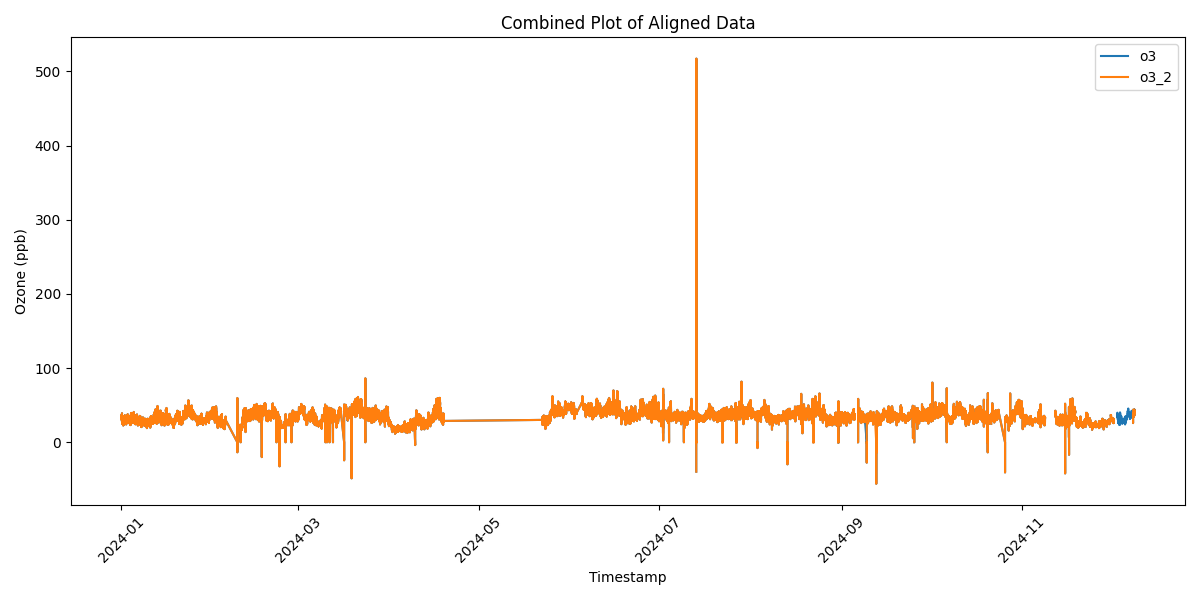

In [5]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# activate the matplotlib widget for Jupyter
%matplotlib widget

# File paths (replace with your actual file paths)
file1 = "data/level1/2024/tei49c.parquet"
# file2 = "data/level1/2024/tei49i.parquet"
file2 = "data/level1/2024/tei49c_.parquet"

# Read data
data1 = pl.read_parquet(file1)
data2 = pl.read_parquet(file2)

# Ensure the 'dtm' column is in datetime format
# data1 = data1.with_columns(pl.col('dtm').str.strptime(pl.Datetime, fmt='%Y-%m-%d %H:%M:%S'))
# data2 = data2.with_columns(pl.col('dtm').str.strptime(pl.Datetime, fmt='%Y-%m-%d %H:%M:%S'))

# Align data on 'dtm' by joining
merged_data = data2.join(data1, on='dtm', how='outer', suffix="_2").sort('dtm')

# Select the columns to plot (replace 'value_column' with actual column names)
column1 = 'o3'
column2 = 'o3_2'

# Fill missing values with NaN for plotting
# merged_data = merged_data.with_columns(
#     [
#         pl.col(column1).cast(pl.Float64).fill_null(np.nan),
#         pl.col(column2).cast(pl.Float64).fill_null(np.nan)
#     ]
# )

# Create a plot
plt.figure(figsize=(12, 6))

# Plot each dataset
plt.plot(merged_data['dtm'], merged_data[column1], label='o3')
plt.plot(merged_data['dtm'], merged_data[column2], label='o3_2')

# Add labels, title, and legend
plt.title("Combined Plot of Aligned Data")
plt.xlabel("Timestamp")
plt.ylabel("Ozone (ppb)")
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


In [1]:
import polars as pl

# File paths (replace with your actual file paths)
file1 = "data/level1/2024/tei49c.parquet"
file2 = "data/level1/2024/None.parquet"

# Read data
data1 = pl.read_parquet(file1)
data2 = pl.read_parquet(file2)

# Ensure the 'dtm' column is in datetime format
# data1 = data1.with_columns(pl.col('dtm').str.strptime(pl.Datetime, fmt='%Y-%m-%d %H:%M:%S'))
# data2 = data2.with_columns(pl.col('dtm').str.strptime(pl.Datetime, fmt='%Y-%m-%d %H:%M:%S'))

# Align data on 'dtm' by joining
data1 = pl.concat([data1, data2], how='diagonal').sort('dtm').unique()
data1.write_parquet("data/level1/2024/tei49c_.parquet")

In [ ]:
src = "/product_data/data/pay/Kenya/MKN/incoming_with_issues/ne300/ne300-202409130100.zip"

if zipfile.is_zipfile(src):
    with zipfile.ZipFile(src, 'r') as zip_file:
        # Get the first CSV file in the archive
        csv_files = [f for f in zip_file.namelist() if f.endswith(('.dat', '.csv'))]
        if not csv_files:
            raise ValueError("No CSV files found in the zip archive.")
        with zip_file.open(csv_files[0]) as fh:
            tmp = fh.readline()
            if len(tmp)==0 or tmp==b'\r\n':
                os.remove(src)
                print(f"{src} removed.")


In [ ]:
from processing.ecc import download_and_extract_shadoz_zip

for year in range(1998, 2023):
    df_data, df_metadata = download_and_extract_shadoz_zip(year=year)

In [ ]:
df = df_data.filter(pl.col('filename')==df_data['filename'][0])
df.describe()

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['O3_mPa'], df['Press'])
plt.yscale('log')
plt.gca().invert_yaxis()

In [ ]:
from processing.cams import convert_cams_nc_to_parquet
for year in range(2003, 2024):
    filepath = f'data/level3/cams/cams-global-reanalysis-eac4-monthly_{year}'
    convert_cams_nc_to_parquet(filepath)

In [ ]:
import time
import polars as pl
import struct
import numpy as np

# Create a large dataset
n = 1_000_000
data = [b'\x00\x00', b'\x00\x01\x02', b'\x01\x00\x03', b'\xff\xff\xab'] * (n // 4)
df = pl.DataFrame({"operation": data})

# Method 1: .apply(lambda)
start = time.time()

def bytes_to_float(byte_str):
    if len(byte_str) != 3:
        raise ValueError("Expected a 2-byte string.")
    int_value = struct.unpack('H', byte_str)[0]  # Unsigned short (16-bit)
    return float(int_value)

df_apply = df.with_columns(
    pl.col("operation").map_elements(bytes_to_float).alias("operation_float")
)

apply_time = time.time() - start
print(f"Apply method took {apply_time:.2f} seconds")

# Method 2: Vectorized NumPy implementation
start = time.time()

def byte_to_float_vectorized(byte_array):
    bytes_np = np.frombuffer(b"".join(byte_array), dtype=np.uint16)
    return bytes_np.astype(np.float32)

df_vectorized = df.with_columns(
    pl.Series("operation_float", byte_to_float_vectorized(df["operation"].to_list()))
)

vectorized_time = time.time() - start
print(f"Vectorized method took {vectorized_time:.2f} seconds")


In [ ]:
data = [b'\x00\x00\x00', b'\x00\x00\x01', b'\x01\x00\x00', b'\xff\x00\xff']
df = pl.DataFrame({"operation": data})


In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df_pl['O3_mPa'], df_pl['level'])
plt.yscale('log')
plt.gca().invert_yaxis()

In [ ]:
# [TODO] Plot the model data together with the sonde data to see if this makes sense; 
# then use model values to complement ecc sonde profile above burst altitude
# then integrate profile to get TCO.

In [ ]:
# recode flagged data with probability of value (0: invalid, 0.5: uncertain, 1: valid)
#  reformat as dataframe with 'zzzztttt', 'installation', 'parameter', 'probability'
import polars as pl
df = pl.read_parquet("data/level2/2021/vrxa00.parquet")

# select only data where at least one parameter was flagged
df = df.select(pl.col('zzzztttt'), 
          pl.col('^f_.*$'),).filter(pl.any_horizontal(pl.col('^f_.*$')>0))
print(df.describe())

# recode flags
mapper = {
    0: 1,
    1: 0,
    2: 0.5,
}
df = df.select(
    pl.all().replace(mapper)
)

# reshape dataframe

df.write_csv("data/level2/2021/vrxa00_probalities.csv")

df = pl.read_parquet("data/level2/2022/vrxa00.parquet")
df = df.select(pl.col('zzzztttt'), 
          pl.col('^f_.*$'),).filter(pl.any_horizontal(pl.col('^f_.*$')>0))
print(df.describe())

mapper = {
    0: 1,
    1: 0,
    2: 0.5,
}
df = df.select(
    pl.all().replace(mapper)
)
df.write_csv("data/level2/2022/vrxa00_probalities.csv")


In [ ]:
# import os
# import polars as pl
# from processing.meteo import Meteo
# met = Meteo()

# source = os.path.join(os.getcwd(), "data/level1/2022/vrxa00.parquet")
# df = pl.read_parquet(source)
# display(df.describe())

# variable = "ta2200s0"
# variable = "fkl010z0"
# variable = "fa1010z0"
# variable = "fkl010z1"
# variable = "tre200s0"
# met.plot_data(df, variable=variable)

In [ ]:
# # Automatic flagging of outliers
# import numpy as np
# import pandas as pd
# from sklearn.neighbors import LocalOutlierFactor
# import matplotlib.pyplot as plt

# # Generate a sample time series temperature dataset
# np.random.seed(42)
# timestamps = pd.date_range(start="2024-01-01", end="2024-01-31", freq="H")
# temperatures = np.random.normal(loc=20, scale=5, size=len(timestamps))

# # Introduce some outliers
# temperatures[10] = 40
# temperatures[20] = 5

# # Create a DataFrame
# df = pd.DataFrame({"Timestamp": timestamps, "Temperature": temperatures})

# # Extract temperature values as a 1D array
# temperature_values = df["Temperature"].values.reshape(-1, 1)

# # Use the Sub-LOF method to detect outliers
# lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
# outliers = lof.fit_predict(temperature_values)

# # Add the outlier labels to the DataFrame
# df["Outlier"] = outliers

# # Plot the time series with outliers highlighted
# plt.figure(figsize=(10, 6))
# plt.plot(df["Timestamp"], df["Temperature"], label="Temperature")
# plt.scatter(df["Timestamp"][df["Outlier"] == -1], df["Temperature"][df["Outlier"] == -1], color='red', label="Outliers")
# plt.title("Time Series with Outliers Detected using Sub-LOF")
# plt.xlabel("Timestamp")
# plt.ylabel("Temperature")
# plt.legend()
# plt.show()


In [ ]:
# import os
# source = os.path.join("/product_data/data/pay/Kenya/MKN/incoming/g2401")
# by = "month" # "year"
# years = ["20{:2d}".format(yy) for yy in range(20, 30, 1)]
# months = ["{:02d}".format(mm) for mm in range(1, 13, 1)]

# for year in years:
#     if by=="month":
#         for month in months:
#             base = os.path.join(source, year, month)        
#             if os.path.exists(base):
#                 for root, dirs, files in os.walk(base):
#                     print(f"base: {base}")                
#                     print(f"root: {root}")
#                     print(f"files: {len(files)}")
#     elif by=="year":
#         base = os.path.join(source, year)        
#         if os.path.exists(base):
#             for root, dirs, files in os.walk(base):
#                 print(f"base: {base}")                
#                 print(f"root: {root}")
#                 print(f"files: {len(files)}")


In [ ]:
# # Concatenate the individual DataFrames into a single one
# combined_data = pl.concat(dataframes)

# # Assuming you have datetime columns, replace 'datetime_column' with the actual column name.
# datetime_column = 'timestamp'

# # Perform aggregation by datetime_column
# agg_data = (
#     combined_data
#     .with_column(combined_data[datetime_column].cast(pl.Date32))
#     .groupby(datetime_column)
#     .agg(pl.sum(combined_data['value_column']))
#     .sort(datetime_column)
# )

In [ ]:
# # Example of using ECOD for outlier detection
# # Author: Yue Zhao <zhaoy@cmu.edu>
# # License: BSD 2 clause
# # adapted from: https://github.com/yzhao062/pyod/blob/master/examples/ecod_example.py

# from __future__ import division
# from __future__ import print_function

# import os
# import sys

# # temporary solution for relative imports in case pyod is not installed
# # if pyod is installed, no need to use the following line
# # sys.path.append(
# #     os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

# from pyod.models.ecod import ECOD
# from pyod.utils.data import generate_data
# from pyod.utils.data import evaluate_print
# from pyod.utils.example import visualize

# contamination = 0.1  # percentage of outliers
# n_train = 200  # number of training points
# n_test = 100  # number of testing points

# # Generate sample data
# X_train, X_test, y_train, y_test = \
#     generate_data(n_train=n_train,
#                     n_test=n_test,
#                     n_features=2,
#                     contamination=contamination,
#                     random_state=42)

# # train ECOD detector
# clf_name = 'ECOD'
# # clf = ECOD()

# # you could try parallel version as well.
# clf = ECOD(n_jobs=2)
# clf.fit(X_train)

# # get the prediction labels and outlier scores of the training data
# y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)
# y_train_scores = clf.decision_scores_  # raw outlier scores

# # get the prediction on the test data
# y_test_pred = clf.predict(X_test)  # outlier labels (0 or 1)
# y_test_scores = clf.decision_function(X_test)  # outlier scores

# # evaluate and print the results
# print("\nOn Training Data:")
# evaluate_print(clf_name, y_train, y_train_scores)
# print("\nOn Test Data:")
# evaluate_print(clf_name, y_test, y_test_scores)

# # visualize the results
# visualize(clf_name, X_train, y_train, X_test, y_test, y_train_pred,
#             y_test_pred, show_figure=True, save_figure=False)